In [133]:
#DECISION TREE ALGORITHM

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn import tree
from sklearn.preprocessing import LabelEncoder

In [134]:
df=pd.read_csv("loan_approval_dataset.csv")

In [135]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [136]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [138]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [139]:
df.shape

(4269, 13)

In [140]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [141]:
df.drop_duplicates()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [142]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool

In [143]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [144]:
df[' education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [145]:
#class imbalance
df[' education'].value_counts()

 education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

#there is no class inbalance so no need to do operations

#smote, undersampling, oversampling types

In [146]:
df[' self_employed'].value_counts()

 self_employed
Yes    2150
No     2119
Name: count, dtype: int64

In [147]:
 df[' loan_status'].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [148]:
#handling missing vlaues
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

#no need of handling missing values since all are 0

#no need feature scaling  for tree based algorithms, its only for distance based algorithms

#convert categorical to numerical-label encoding,one hot encoding,target variable

#one hot encoding - creates n columns for n unique values-maps 0 n 1

#label encoding only for 3 or 4 values, not more than,if so use one hot encoding 

In [149]:
#label encoding code
cat_cols=df.select_dtypes(include="object").columns
le=LabelEncoder()
for i in cat_cols:
    df[i]=le.fit_transform(df[i])

In [150]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [151]:
X = df.drop(columns = ' loan_status', axis=1)
Y = df[' loan_status']

In [152]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=56)
dt=DecisionTreeClassifier(max_depth = 4, random_state=42)
dt.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [153]:
pred_Y = dt.predict(X_test)

print("Classification Report: ", classification_report(Y_test, pred_Y))
print("Confusion Matrix: ", confusion_matrix(Y_test, pred_Y))
print("Accuracy Model: ", accuracy_score(Y_test, pred_Y))

Classification Report:                precision    recall  f1-score   support

           0       0.96      1.00      0.98       558
           1       0.99      0.93      0.96       296

    accuracy                           0.97       854
   macro avg       0.98      0.96      0.97       854
weighted avg       0.97      0.97      0.97       854

Confusion Matrix:  [[556   2]
 [ 22 274]]
Accuracy Model:  0.9718969555035128


#confusion matrix-create an 2d array -TP-TN-FP-FN
#examples for FP-CREDIT CARD ANALYSIS, FRAUD DETECTION
#examples for FN-FOR HEATHCARE (0 is good)
#recall or specificity 
#f1 score- f beta score
#support

[Text(0.5, 0.9, ' cibil_score <= 549.5\ngini = 0.474\nsamples = 3415\nvalue = [2098, 1317]\nclass = Approved'),
 Text(0.29411764705882354, 0.7, ' loan_term <= 5.0\ngini = 0.185\nsamples = 1456\nvalue = [150, 1306]\nclass = Not Approved'),
 Text(0.3970588235294118, 0.8, 'True  '),
 Text(0.23529411764705882, 0.5, ' loan_amount <= 26250000.0\ngini = 0.5\nsamples = 291\nvalue = [150.0, 141.0]\nclass = Approved'),
 Text(0.11764705882352941, 0.3, ' income_annum <= 7050000.0\ngini = 0.493\nsamples = 246\nvalue = [108, 138]\nclass = Not Approved'),
 Text(0.058823529411764705, 0.1, 'gini = 0.498\nsamples = 194\nvalue = [103, 91]\nclass = Approved'),
 Text(0.17647058823529413, 0.1, 'gini = 0.174\nsamples = 52\nvalue = [5, 47]\nclass = Not Approved'),
 Text(0.35294117647058826, 0.3, ' residential_assets_value <= 400000.0\ngini = 0.124\nsamples = 45\nvalue = [42, 3]\nclass = Approved'),
 Text(0.29411764705882354, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Not Approved'),
 Text(0.411764

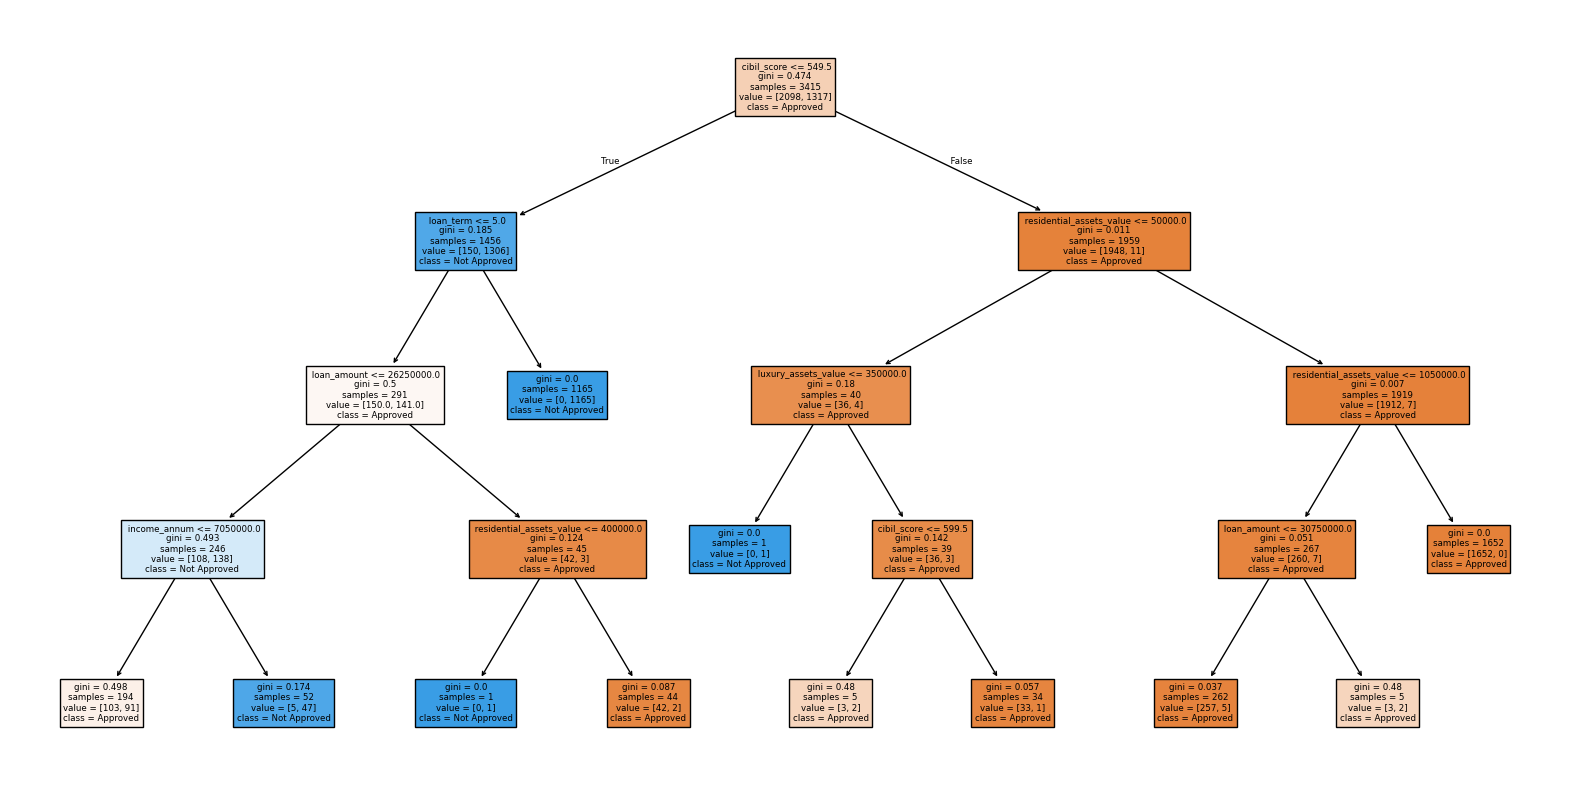

In [154]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names = ["Approved", "Not Approved"],
    filled=True
)

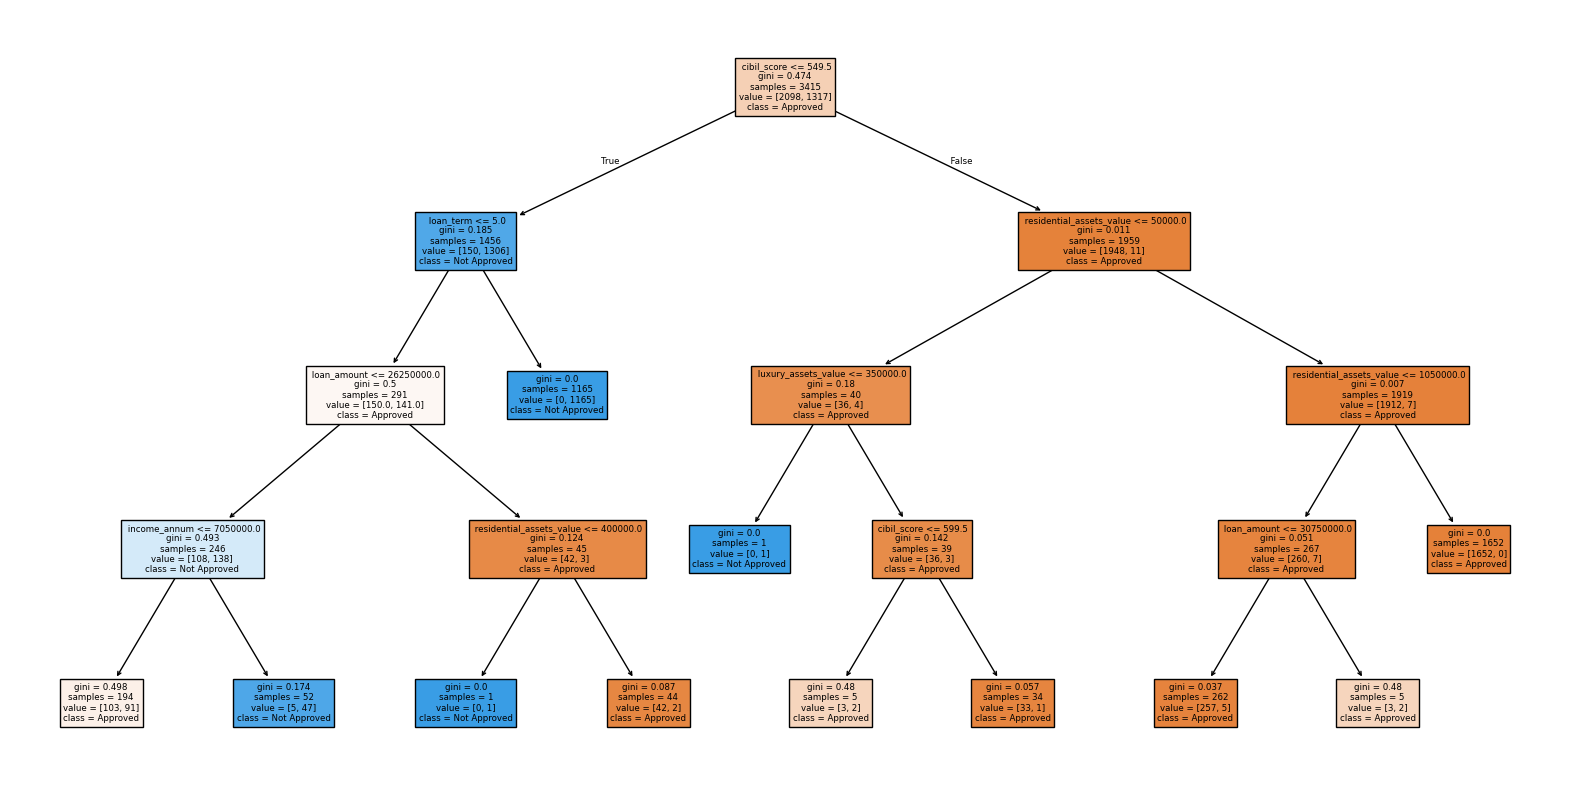

In [155]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt,
    feature_names=X.columns,
    class_names = ["Approved", "Not Approved"],
    filled=True
)
plt.show()

#each node splits to 2- sklearn uses IDE3 AND kart
#depth-levels of splits(height)
#root node-parent node
#leaf node - no split after that condition
#branches-where spliting happens
#pruning-to overcone overfitting(after that tree gets cuts off)
#classification model- classification metrics- f1 score, precision, accuracy 
#Regresssion metrics-MSE, MAE, RMSE, R2 score